## Superstore Dataset EDA

Import necessary libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

getting insight of the data 

In [25]:
df = pd.read_csv("data/superstore_dataset.csv")
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,CA-2019-141817,2019-01-05,2019-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   str    
 1   Order Date     9994 non-null   str    
 2   Ship Date      9994 non-null   str    
 3   Ship Mode      9994 non-null   str    
 4   Customer ID    9994 non-null   str    
 5   Customer Name  9994 non-null   str    
 6   Segment        9994 non-null   str    
 7   Country        9994 non-null   str    
 8   City           9994 non-null   str    
 9   State          9994 non-null   str    
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   str    
 12  Product ID     9994 non-null   str    
 13  Category       9994 non-null   str    
 14  Sub-Category   9994 non-null   str    
 15  Product Name   9994 non-null   str    
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount       9994

In [27]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [28]:
df.isnull().sum()
# we have no null values

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [29]:
df.duplicated().sum()


# how to drop duplicates


df.drop_duplicates(inplace=True)

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
# first specify category columns


categorical_columns = ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
                       'Category', 'Sub-Category', 'Product Name']

for col in categorical_columns:
    print(df[col].value_counts())

Ship Mode
Standard Class    5967
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64
Segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64
Country
United States    9993
Name: count, dtype: int64
City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Seattle          428
                ... 
Whittier           1
Palatine           1
Abilene            1
Port Orange        1
Danbury            1
Name: count, Length: 531, dtype: int64
State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     468
Florida                  383
Michigan                 255
North Carolina           249
Virginia                 224
Arizona                  224
Georgia                  184
Tennessee                183
Colorado                 182
Indian

In [32]:
df.describe(include='str')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9993,9993,9993,9993,9993,9993,9993,9993,9993,9993,9993,9993,9993,9993,9993
unique,5009,1237,1332,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2022-100111,2021-09-05,2020-12-15,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5967,37,37,5191,9993,915,2001,3203,19,6026,1523,48


In [33]:
# check the number of uniquness of categorical featuers

cat_cols = df.select_dtypes(include='str').columns

for cat in cat_cols:
    print(cat, df[cat].nunique())

Order ID 5009
Order Date 1237
Ship Date 1332
Ship Mode 4
Customer ID 793
Customer Name 793
Segment 3
Country 1
City 531
State 49
Region 4
Product ID 1862
Category 3
Sub-Category 17
Product Name 1850


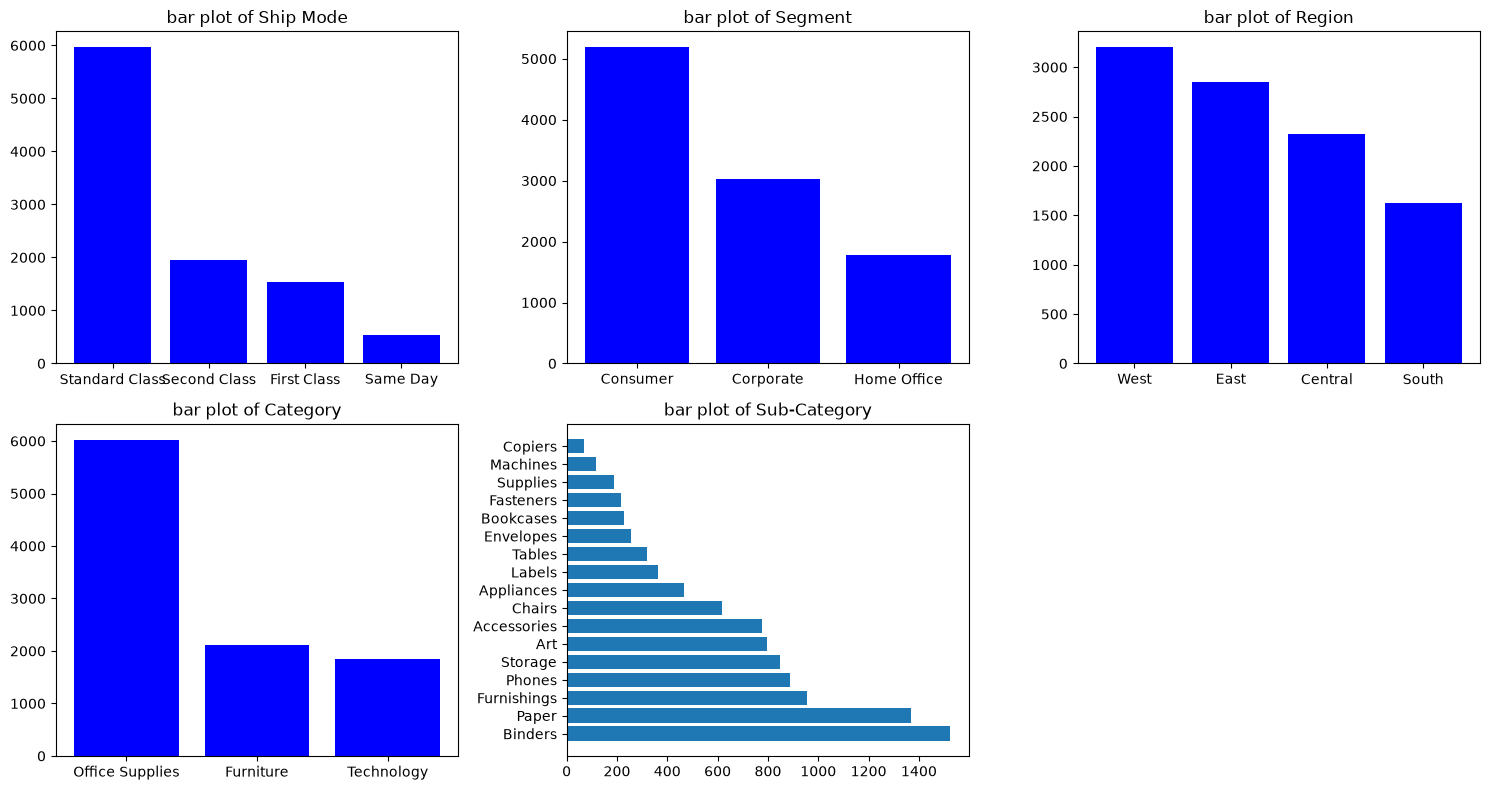

In [34]:
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    
    if col != 'Sub-Category':
        axes[i].bar(counts.index, counts.values, color='blue')
    else:
        axes[i].barh(counts.index, counts.values)

    axes[i].set_title(f"bar plot of {col}")

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])



plt.tight_layout()
plt.show()

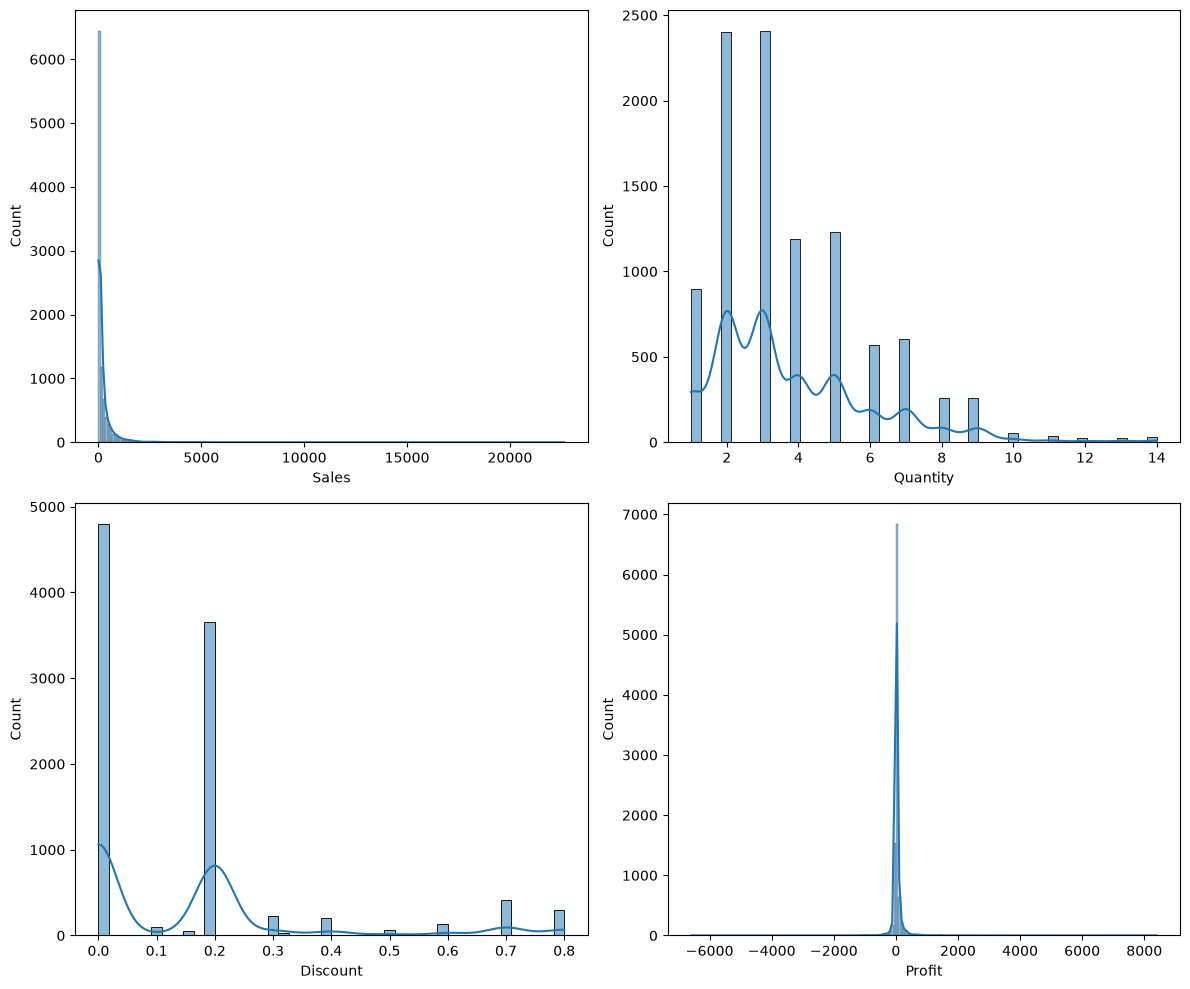

In [38]:
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Postal Code')

n = len(num_cols)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

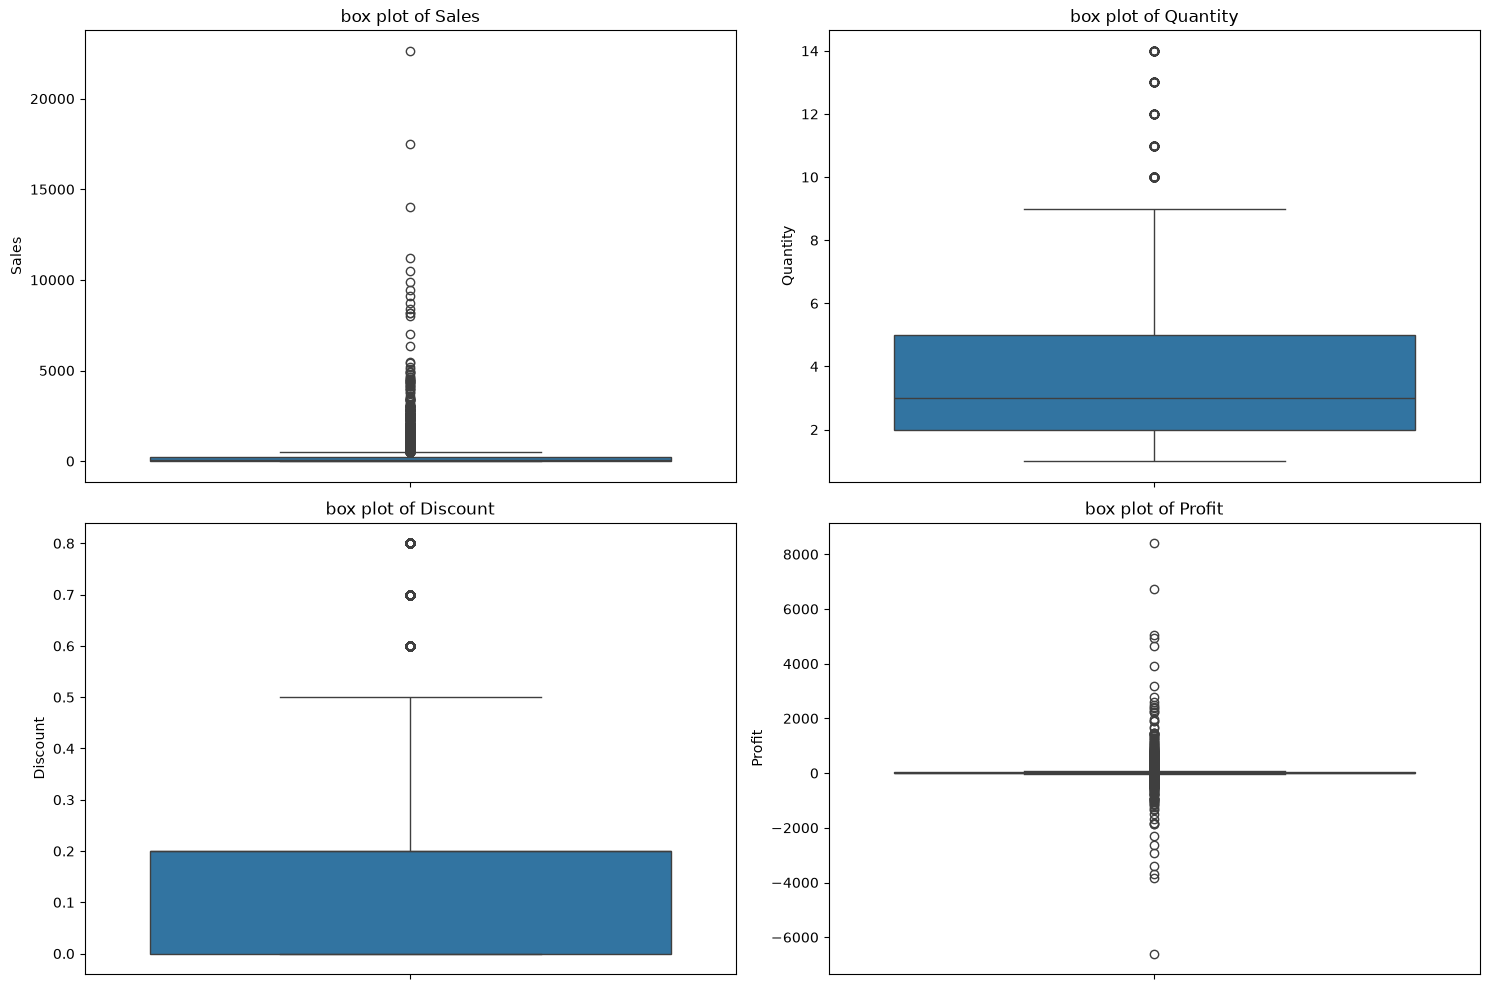

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Postal Code')

cols = 2
rows = math.ceil(len(num_cols) / cols)

fig , axis = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axis = axis.flatten()

for i , col in enumerate(num_cols):
    sns.boxplot(df[col], ax=axis[i])
    axis[i].set_title(f"box plot of {col}")


# deleting empty subplots


for j in range(len(num_cols), len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()



As it can be seen Sales and Profit are highly skewed . so to get a better EDA we plot their histogram one more time

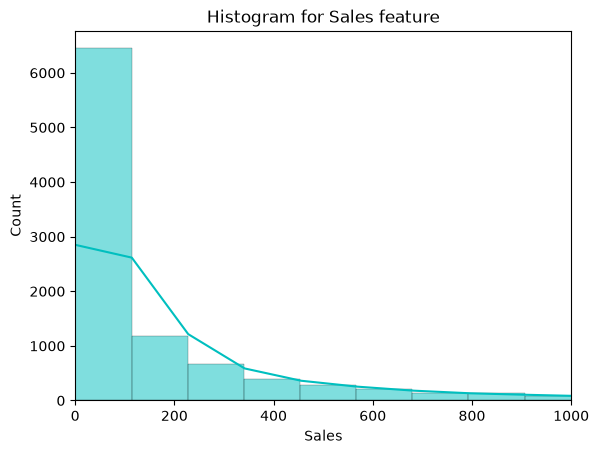

In [ ]:
sns.histplot(df['Sales'], kde=True, color='c')
plt.title("Histogram for Sales feature")
plt.xlim(0, 1000)
plt.show()

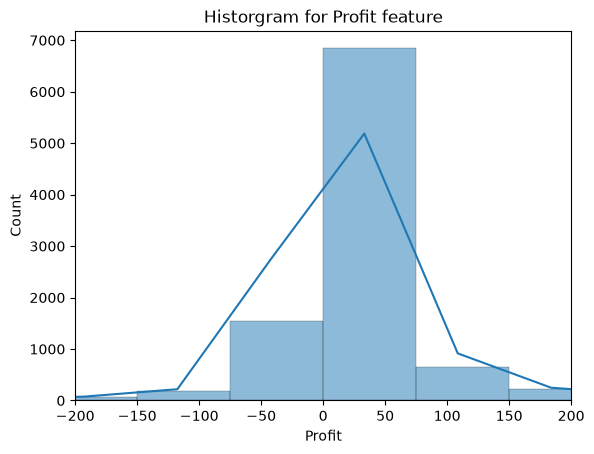

In [ ]:
sns.histplot(df['Profit'], kde=True)
plt.xlim(-200, 200)
plt.title("Historgram for Profit feature")
plt.show()

In order to make sure about the skewness of the both Profit and Sales features we can call .skew() function on them

1. -0.5 to 0.5 -> approximatly symmetric
2. 0.5 to 1 -> moderatly skewed
3. being bigger than 1 means highly skewed

In [ ]:
print('measurement of skewnes for Sales',df['Sales'].skew())
print('measurement of skewnes for Sales', df['Profit'].skew())

measurement of skewnes for Sales 12.972141558363262
measurement of skewnes for Sales 7.561035996041442


Now let's find the outliers for highly skewed features using IQR 

$IQR = Q3 - Q1$

$Lower bound = Q1 - 1.5 * IQR$

$Upper bound = Q3 + 1.5 * IQR$

anything lower than lower bound or higher than upper bound is considerd an outlier

Now let's find the number of outliers for each numerical feature


In [ ]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) |
                (df[col] > upper)).sum()
    
    print(col, outliers)

Sales 1167
Quantity 170
Discount 856
Profit 1881


Next step we go to analyze the correlation between features 

In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

             Postal Code     Sales  Quantity  Discount    Profit
Postal Code     1.000000 -0.023851  0.012731  0.058471 -0.029968
Sales          -0.023851  1.000000  0.200808 -0.028197  0.479067
Quantity        0.012731  0.200808  1.000000  0.008680  0.066241
Discount        0.058471 -0.028197  0.008680  1.000000 -0.219481
Profit         -0.029968  0.479067  0.066241 -0.219481  1.000000


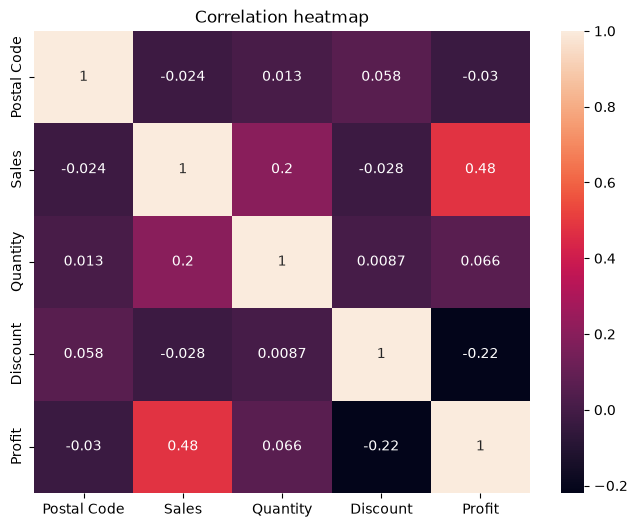

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True)
plt.title('Correlation heatmap')
plt.show()

Now from the heatmap above we figure that Sales and Profit are correlated with a strong coeffient of 0.48 so we plot the scatter plot of them to have a better sense of how they correlate with eachother

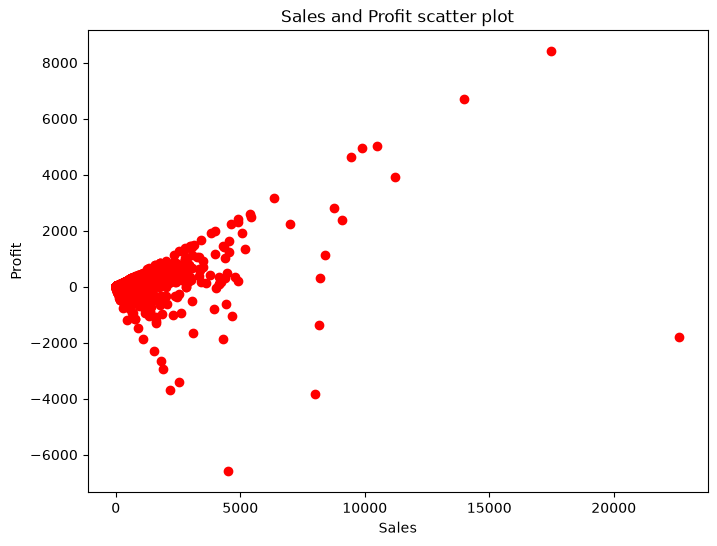

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Sales'], df['Profit'], c='r')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales and Profit scatter plot')
plt.show()

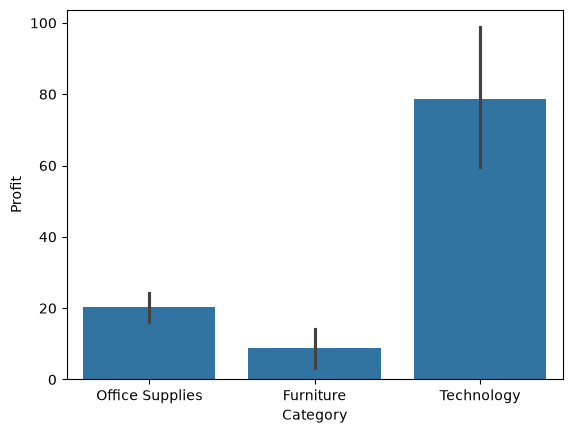

In [ ]:
sns.barplot(x='Category', y='Profit', data=df)
plt.show()

In [43]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18463.3316
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

from the bar plot above we can clearly see that Technology has the biggest share in profit by far

now let's check the profit per Sub-Category

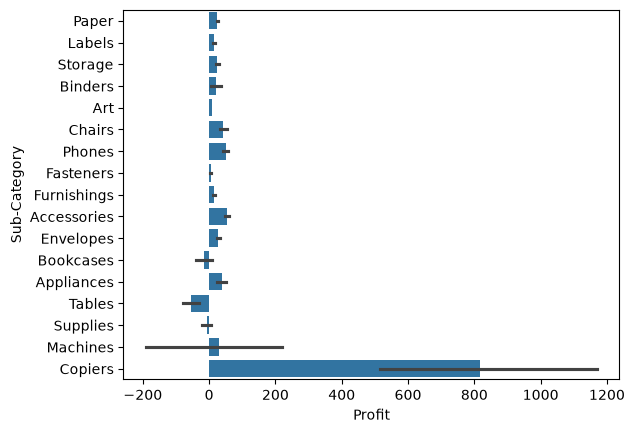

In [47]:
sns.barplot(x='Profit', y='Sub-Category', data=df)
plt.show()

Now let's check the profit based on segment and region

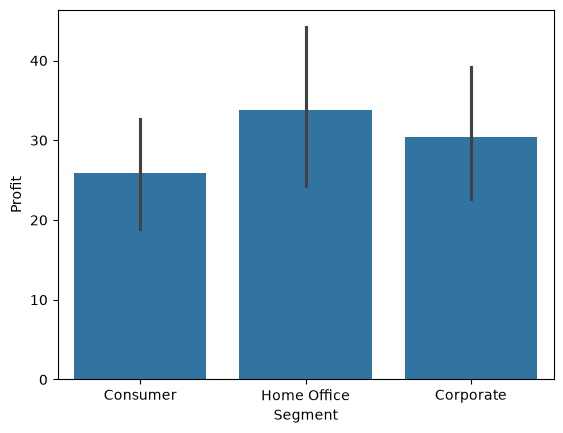

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60310.7373
Name: Profit, dtype: float64

In [51]:
sns.barplot(data=df, x='Segment', y='Profit')
plt.show()

df.groupby('Segment')['Profit'].sum()

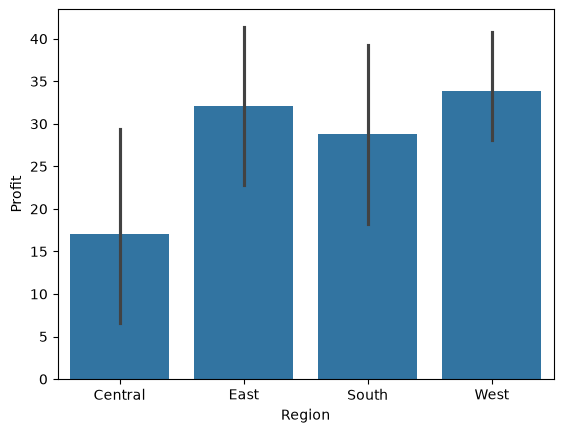

Region
Central     39706.3625
East        91534.8388
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

In [55]:
sns.barplot(data=df, x='Region', y='Profit')
plt.show()

df.groupby('Region')['Profit'].sum()

Time Series Analysis

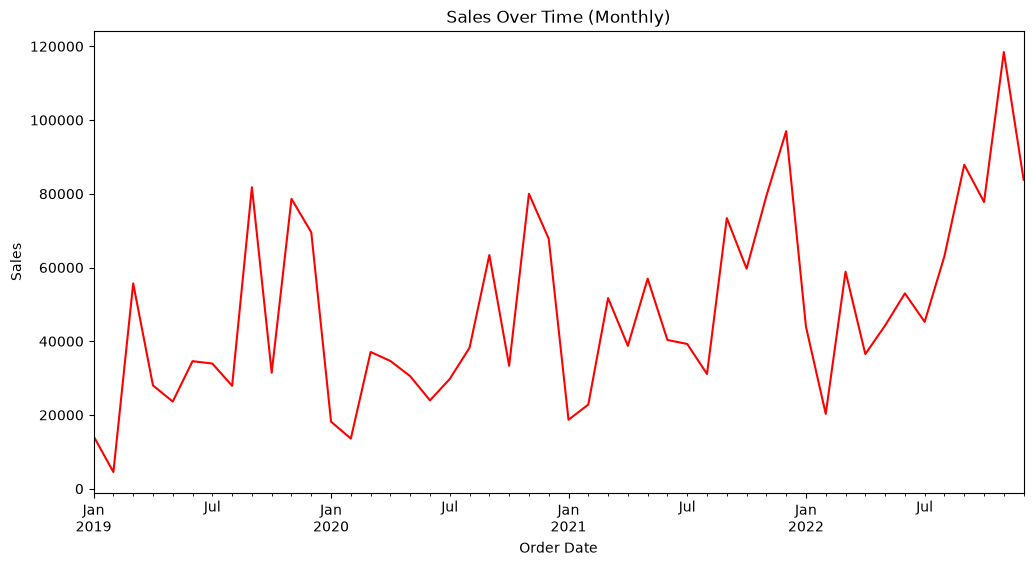

In [74]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()


monthly_sales.plot(kind='line', figsize=(12, 6), c='r')
plt.title("Sales Over Time (Monthly)")
plt.ylabel('Sales')
plt.show()

